# Classification

## MNIST

MNIST is a dataset of 70,000 small images of digits.
It is a good test of classification algorithms.

In [2]:
from sklearn.datasets import fetch_openml

In [4]:
mnist = fetch_openml('mnist_784', as_frame=False)

In [5]:
X, y = mnist.data, mnist.target

In [6]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [7]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

Each have 784 features since they are 28 x 28 images

The pixels have values from 0 (white) to 255 (black)

In [8]:
X.shape

(70000, 784)

In [9]:
y.shape

(70000,)

In [10]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [11]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis("off")

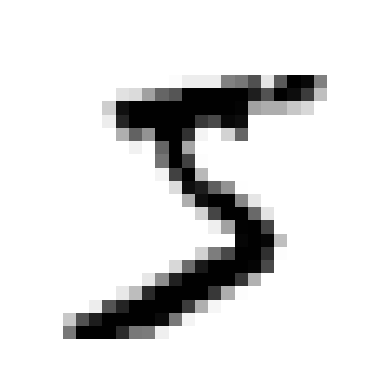

In [12]:
some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [13]:
y[0]

'5'

split to train and test

In [14]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Training a Binary Classifier

Train a 5 classifier

It is binary as it will return 5 or non-5

In [15]:
y_train_5 = (y_train == '5') # True for all 5's, False for all other digits
y_test = (y_test == '5')

Stochaistic Gradient Descent Classifier - Good for large datasets since it trains instances independently

In [16]:
from sklearn.linear_model import SGDClassifier

In [17]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


Now we can detect with classifier

In [18]:
sgd_clf.predict([some_digit])

array([ True])

#### Evaluate Models Performance

use k-fold cross-validation to determine performance

In [19]:
from sklearn.model_selection import cross_val_score

In [20]:
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

lets check a dummy classifier, 95% accuracy seems high

In [22]:
from sklearn.dummy import DummyClassifier

In [24]:
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


the above detected no 5's, which is wrong

In [25]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.90965, 0.90965, 0.90965])

Over 90% accuracy on dummy classifier

This is because only 10% of images are 5's in the data

so if you always guess not 5, you have 90% accuracy

This shows why accuracy isnt a good metric especially if the data is skewed

Only 10% of data falls into 5's vs 90% not 5's

#### Confusion Matrix

count number of times instances of class A are classified as class B
for all A/B pairs

In [27]:
# compare predictions to actual targets
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

returns predictions made on each test fold, getting a clean orediction for each instance in the training set

In [29]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

The rows represent actual class while columns represent predicted class

53892 correctly identified as non 5 (true negative)

687 wrongly identified as non-5s (false positives or type I errors)

1891 wrongly identified as 5s (false negatives or type II errors)

3530 correctly identified as 5s (true positives)

In [30]:
y_train_perfect_predictions = y_train_5 # we pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

another metric to use is precision

precision = True Positives / (True Positives + False Positives)

precision on its own is not enough, since a classifier could only predict on whats its most confident about

ie 

if classifier makes 0 false positives but only one true positive the above will give 100% precision

recall = true positives / (true positives + false negatives)